# Supplementary Data Figure 6

Environment: env1

In [ ]:
import pandas as pd
import pickle
import os
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



import matplotlib as mpl
import sys
sys.path.append("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/")
from utils import plot_avg_roc_from_dicts, plot_avg_pr_from_dicts


In [9]:
dpi = 300
font_size = 12
fig_size = 5

# CU

In [11]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/final_pec_20251017.pkl", "rb") as f:
    pec = pickle.load(f)
with open("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/rev_test_pec_cases_20260406.pkl", "rb") as f:
    pec_test = pickle.load(f)
all_pec = pec + pec_test

In [13]:
pw_results = {}

for pw in range(1, 6):
    pw_predictions = pd.read_csv(f'/gpfs/home/ds7014/shenhavlab/users/Daniel/RETFound/output_loo/retfound_mae_REV_PEC_PW{pw}_LOO_finetune/image_predictions.csv')
    pw_predictions['subject_id'] = pw_predictions['subject_id'].str.lower()

    subject_agg = {}
    epoch_auc = []

    for epoch in range(25):
        pw_predictions_epoch = pw_predictions[pw_predictions['epoch']==epoch]
        average_prob = pw_predictions_epoch[['subject_id', 'pred_prob_class1']].groupby('subject_id', as_index=False).mean()
        average_prob['label'] = average_prob['subject_id'].apply(lambda x: 1 if x in all_pec else 0)
        subject_agg[epoch] = average_prob

        roc_auc = roc_auc_score(average_prob['label'], average_prob['pred_prob_class1'])
        epoch_auc.append(roc_auc)

    best_epoch = epoch_auc.index(max(epoch_auc))

    pw_results[pw] = {'best_epoch': best_epoch, 'best_auc': max(epoch_auc), 'epoch_results': subject_agg[best_epoch]}

proc pw1
proc pw2
proc pw3
proc pw4
proc pw5


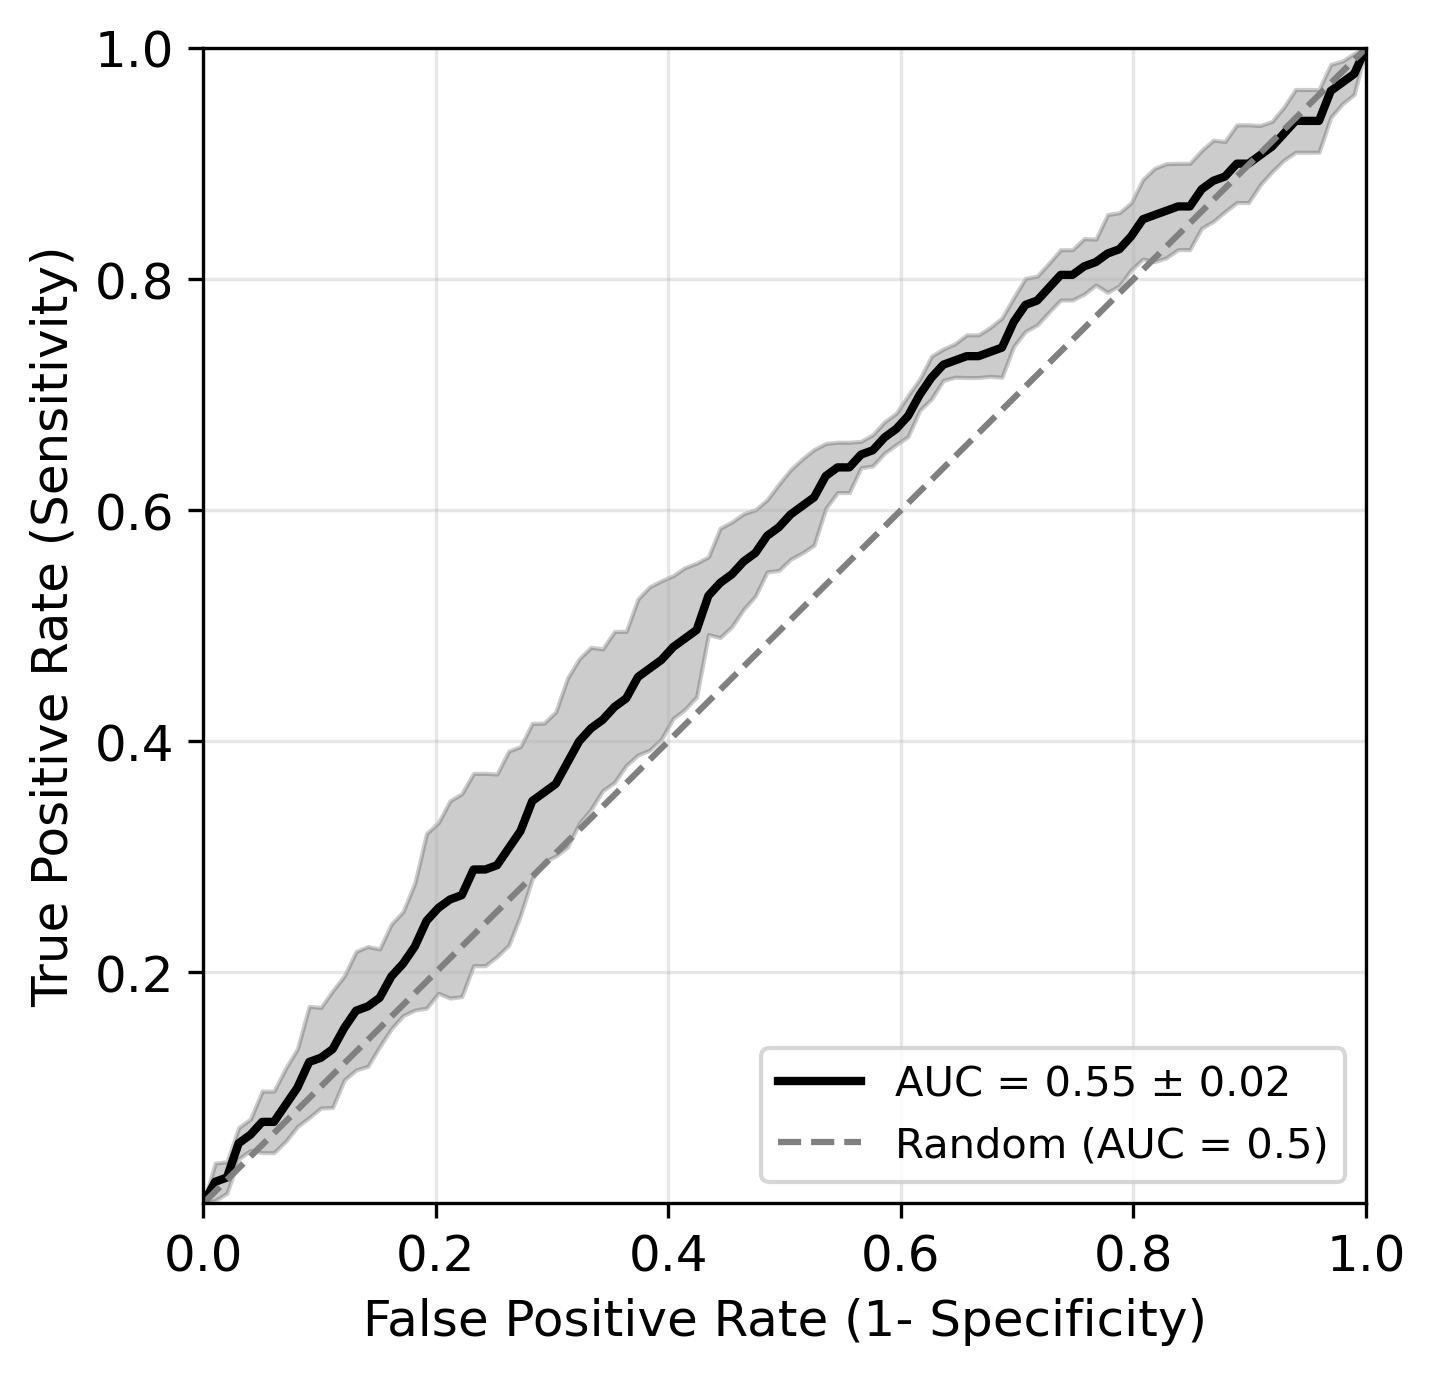

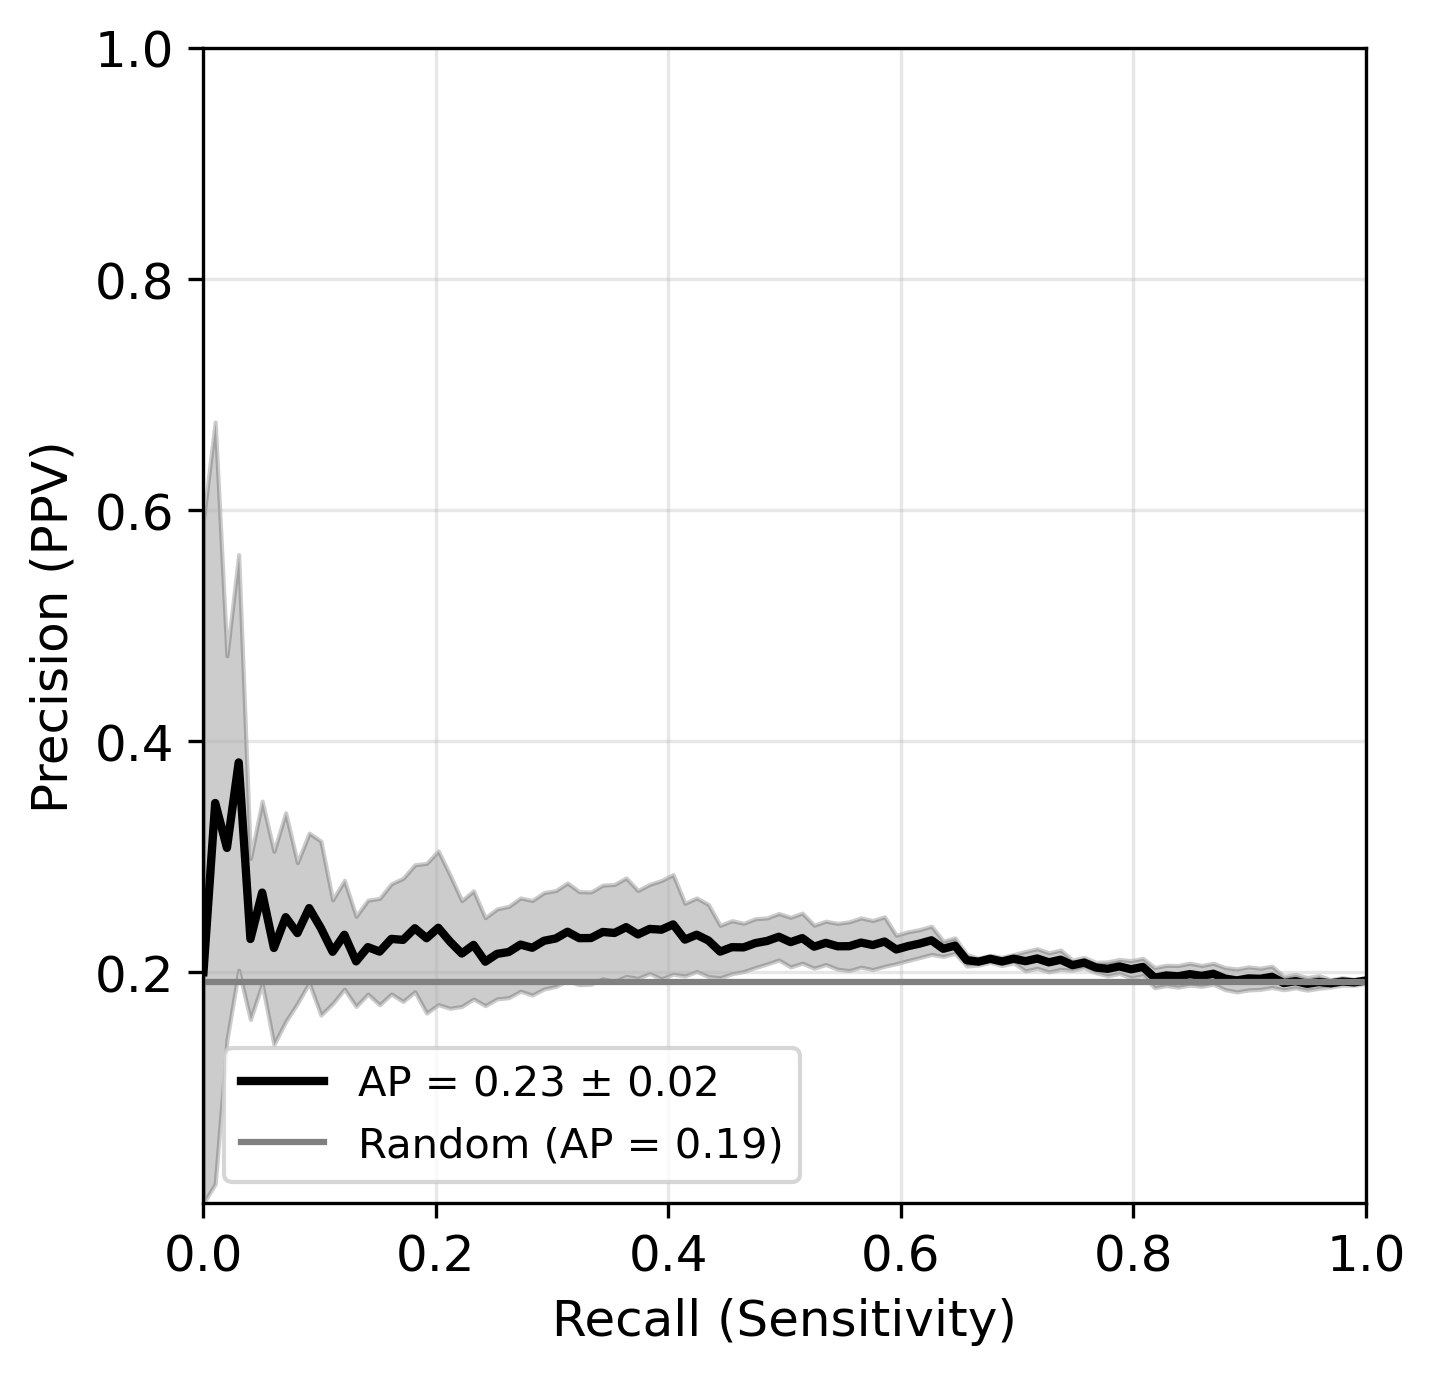

In [ ]:
# ROC

model_type = 'retfound'

plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = pw_results.copy()
cols = ["pred_prob_class1"]

all_labels = True

if all_labels:
    plot_avg_roc_from_dicts(reweight, add_col=cols, plot=True, pw=5, rand=True,#color="#CA3F54",
                           x_label=True, y_label=True, x_ticks=True, y_ticks=True
                           )
else:
    plot_avg_roc_from_dicts(reweight, add_col=cols, plot=True, pw=5, rand=True,#color="#CA3F54",
                       x_label=True, y_label=False, x_ticks=True, y_ticks=False
                       )
plt.title("")
plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/cu_{model_type}_auc.pdf') 
plt.show()

# # PR
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = pw_results.copy()
cols = ["pred_prob_class1"]

if all_labels:
    plot_avg_pr_from_dicts(reweight, plot=True, rand=True,#color="#CA3F54",
                          )
else:
    plot_avg_pr_from_dicts(reweight, plot=True, rand=True,#color="#CA3F54",
                           x_label=True, y_label=False, x_ticks=True, y_ticks=False
                          )
plt.title("")
plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/cu_{model_type}_pr.pdf') 

plt.show()

# NYU

In [16]:
nyu_cases = pd.read_pickle('/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_cases_051126.pkl')

In [ ]:
pw_results = {}

for pw in range(1, 6):
    pw_predictions = pd.read_csv(f'/gpfs/home/ds7014/shenhavlab/users/Daniel/RETFound/output_eval/retfound_mae_REV_NYU_PW{pw}_TRAIN_finetune/image_predictions.csv')
    pw_predictions['subject_id'] = pw_predictions['subject_id'].str.lower()

    subject_agg = {}
    epoch_auc = []

    average_prob = pw_predictions_epoch[['subject_id', 'pred_prob_class1']].groupby('subject_id', as_index=False).mean()
    average_prob['label'] = average_prob['subject_id'].apply(lambda x: 1 if x in all_pec else 0)

    roc_auc = roc_auc_score(average_prob['label'], average_prob['pred_prob_class1'])

    pw_results[pw] = {'auc': roc_auc, 'epoch_results': average_prob}

proc pw1
proc pw2
proc pw3
proc pw4
proc pw5


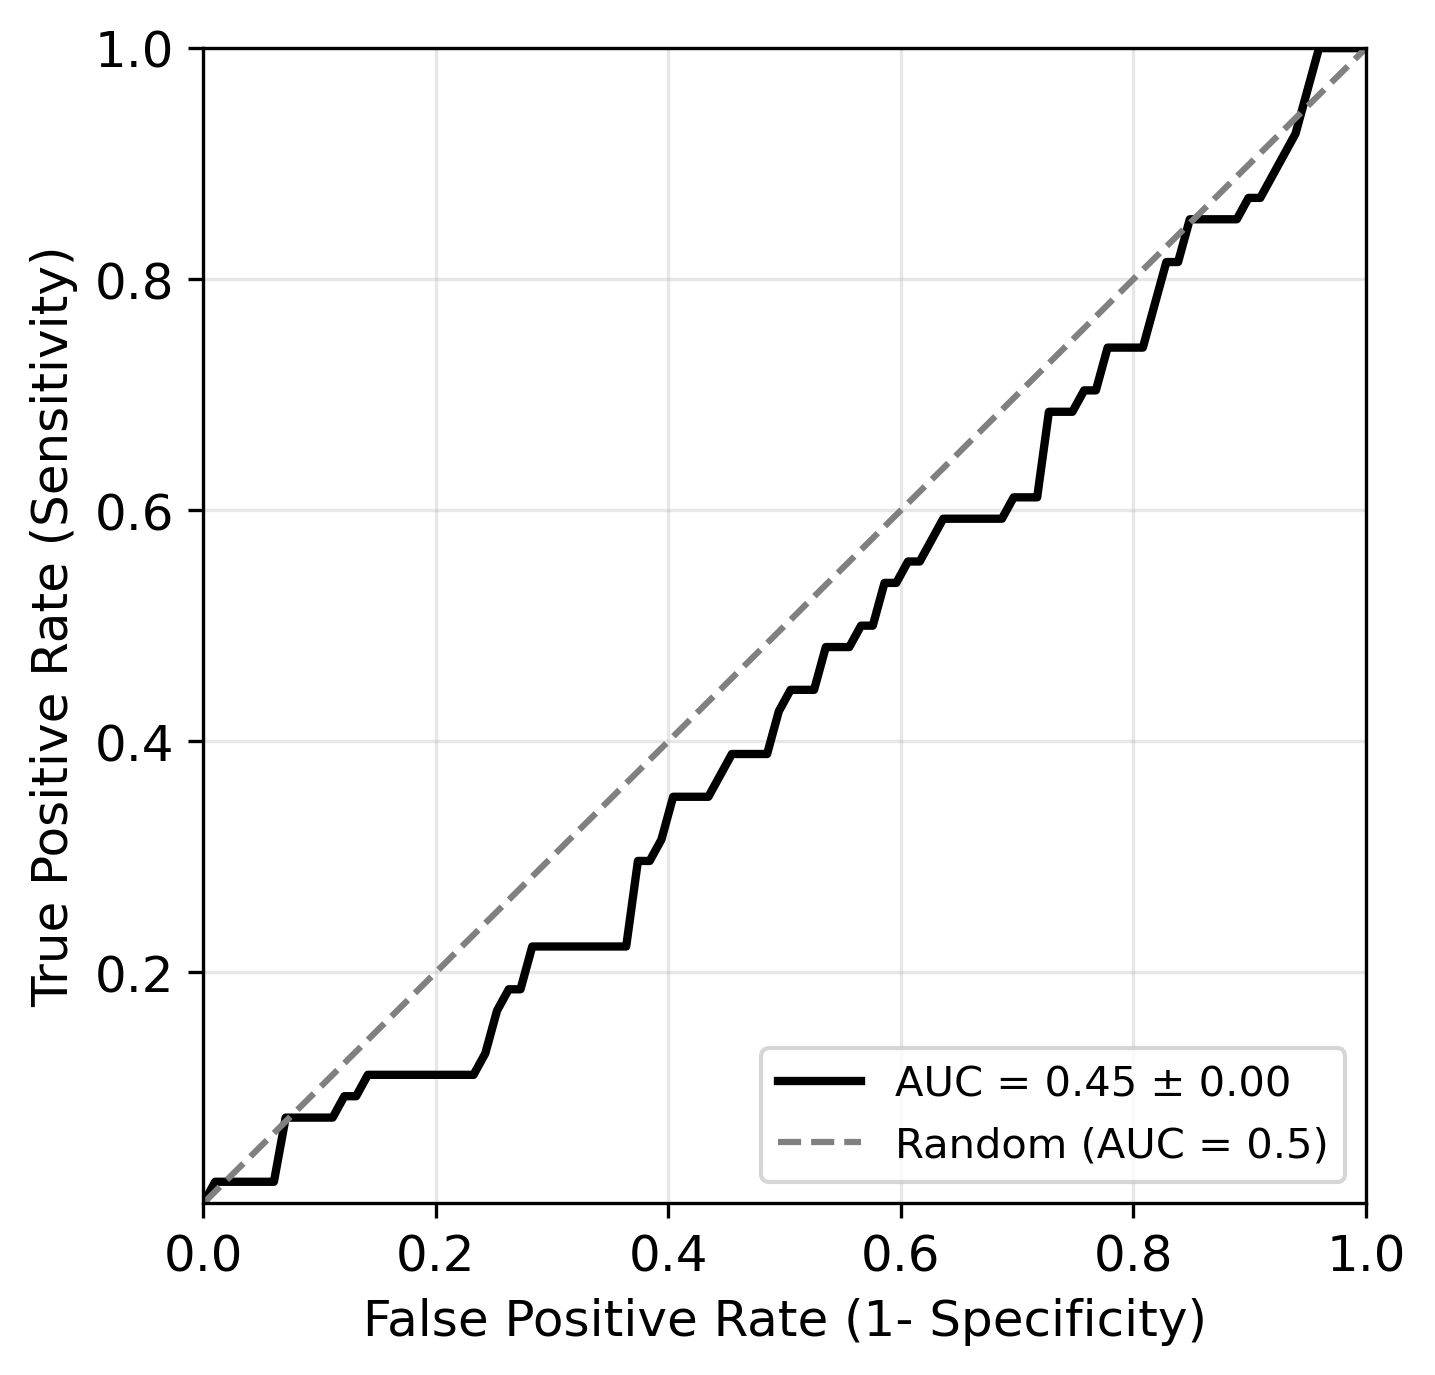

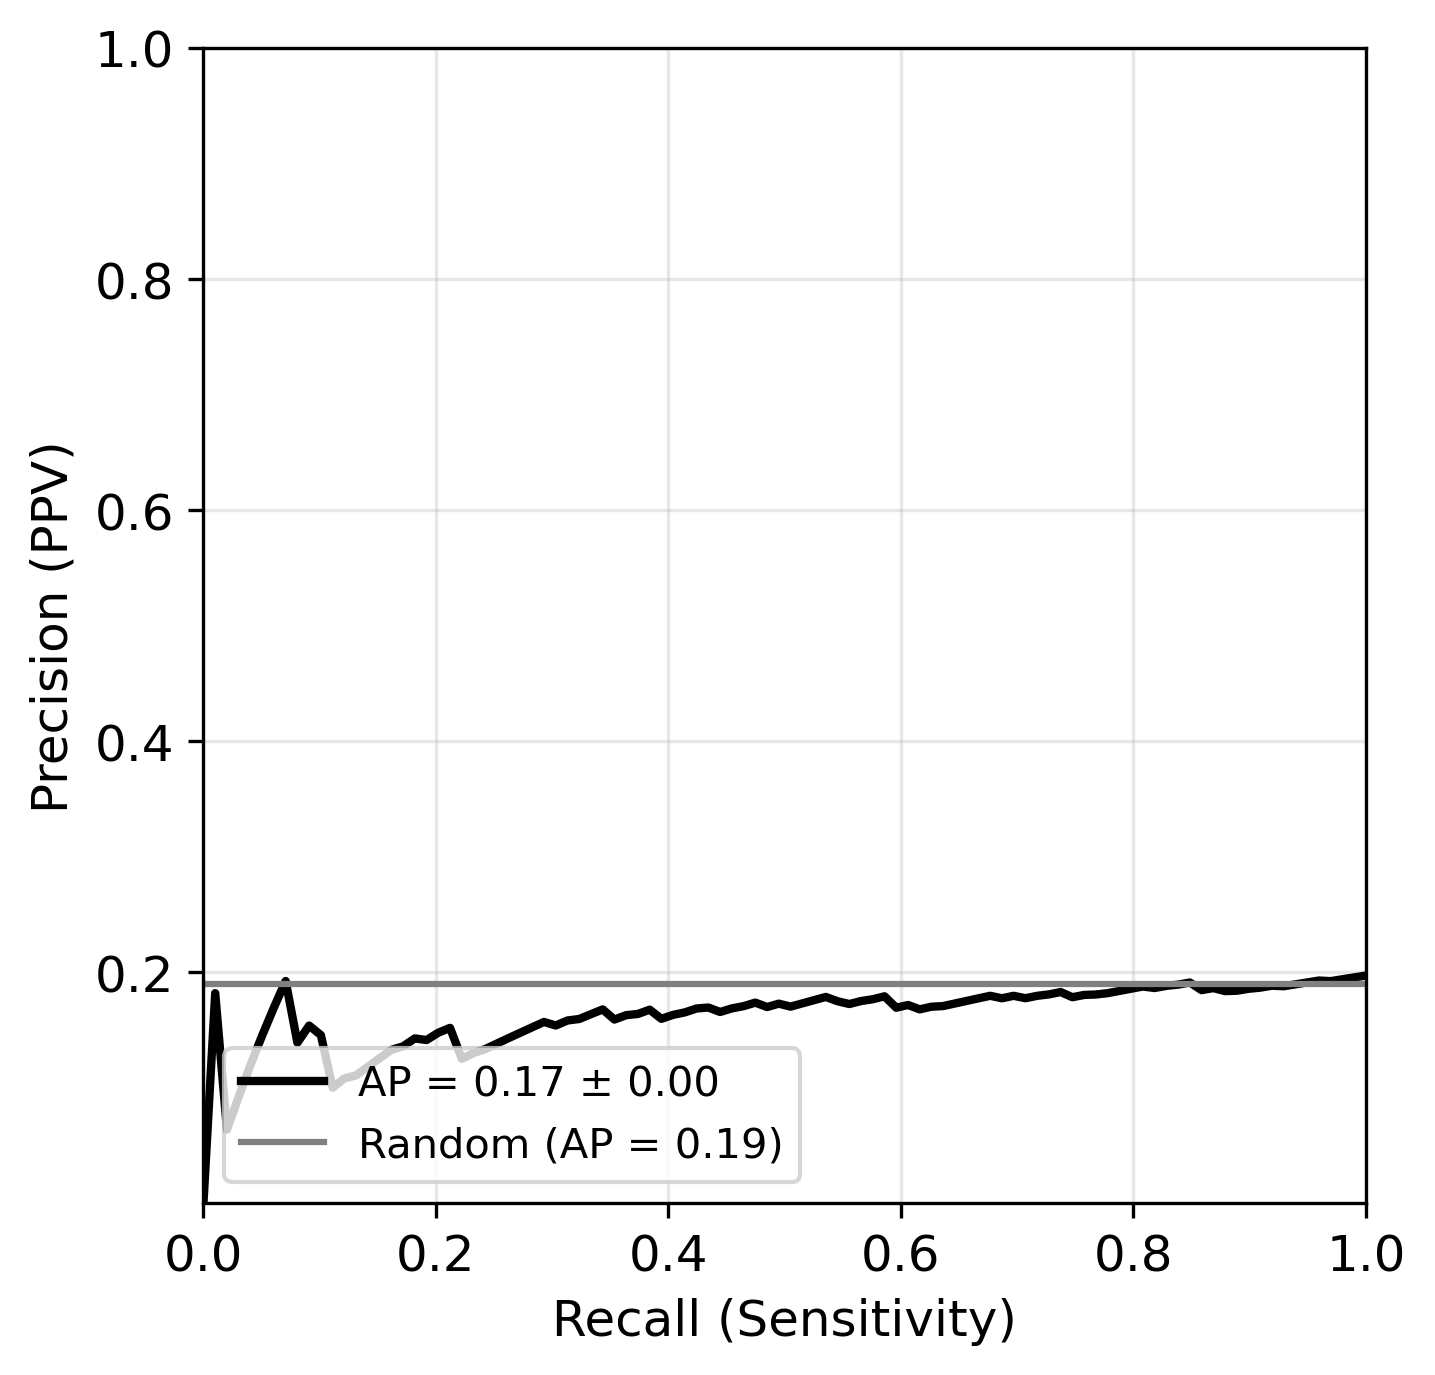

In [ ]:
# ROC

model_type = 'retfound'

plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = pw_results.copy()
cols = ["pred_prob_class1"]

all_labels = True

if all_labels:
    plot_avg_roc_from_dicts(reweight, add_col=cols, plot=True, pw=5, rand=True,
                           x_label=True, y_label=True, x_ticks=True, y_ticks=True
                           )
else:
    plot_avg_roc_from_dicts(reweight, add_col=cols, plot=True, pw=5, rand=True,
                       x_label=True, y_label=False, x_ticks=True, y_ticks=False
                       )
plt.title("")
plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/nyu_{model_type}_auc.pdf') 
plt.show()

# # PR
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = pw_results.copy()
cols = ["pred_prob_class1"]

if all_labels:
    plot_avg_pr_from_dicts(reweight, plot=True, rand=True,
                          )
else:
    plot_avg_pr_from_dicts(reweight, plot=True, rand=True,
                           x_label=True, y_label=False, x_ticks=True, y_ticks=False
                          )
plt.title("")
plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/nyu_{model_type}_pr.pdf') 

plt.show()